In [9]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Загружаем данные из CSV-файлов
users_test = pd.read_csv('Проект_3_users_test.csv', delimiter=';', header=0)
users_control1 = pd.read_csv('Проект_3_users_control_1.csv', delimiter=';', header=0)
users_control2 = pd.read_csv('Проект_3_users_control_2.csv', delimiter=';', header=0)
transactions_test = pd.read_csv('Проект_3_transactions_test.csv', delimiter=';', header=0)
transactions_control1 = pd.read_csv('Проект_3_transactions_control_1.csv', delimiter=';', header=0)
transactions_control2 = pd.read_csv('Проект_3_transactions_control_2.csv', delimiter=';', header=0)

In [17]:
# Добавляем столбец 'group' для каждой выборки
users_test['group'] = 'test'
users_control1['group'] = 'control_1'
users_control2['group'] = 'control_2'

transactions_test['group'] = 'test'
transactions_control1['group'] = 'control_1'
transactions_control2['group'] = 'control_2'

In [18]:
# Объединяем всех пользователей и транзакции в общие датафреймы
all_users = pd.concat([
    users_test,
    users_control1,
    users_control2
], ignore_index=True)

all_transactions = pd.concat([
    transactions_test,
    transactions_control1,
    transactions_control2
], ignore_index=True)

In [20]:
# Группируем пользователей по группам и считаем:
# - общее количество пользователей
# - количество пользователей, которые были премиум (was_premium == True)
conversion_by_group = all_users.groupby('group').agg(
    total_users=('uid', 'count'),
    premium_users=('was_premium', 'sum')
)

# Считаем долю премиум-пользователей (конверсию)
conversion_by_group['conversion_rate'] = conversion_by_group['premium_users'] / conversion_by_group['total_users']
print(conversion_by_group[['total_users', 'premium_users', 'conversion_rate']])

           total_users  premium_users  conversion_rate
group                                                 
control_1         4340          436.0         0.100461
control_2         4264          411.0         0.096388
test              4308          408.0         0.094708


In [21]:
# Суммируем выручку по каждому пользователю в каждой группе
revenue_per_user = all_transactions.groupby(['uid', 'group'])['revenue'].sum().reset_index()

# Объединяем данные о пользователях и их выручке
user_revenue = all_users[['uid', 'group']].merge(revenue_per_user, on=['uid', 'group'], how='left').fillna(0)

# Считаем среднюю выручку на пользователя по группам (ARPU)
arpu_by_group = user_revenue.groupby('group')['revenue'].mean()
print(arpu_by_group)

group
control_1    601.914977
control_2    450.384146
test         544.313138
Name: revenue, dtype: float64


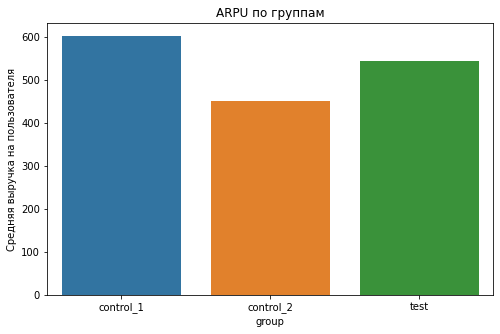

In [22]:
# Строим график ARPU по группам
plt.figure(figsize=(8, 5))
sns.barplot(x=arpu_by_group.index, y=arpu_by_group.values)
plt.title("ARPU по группам")
plt.ylabel("Средняя выручка на пользователя")
plt.show()

In [23]:
# Создаём таблицу с количеством пользователей, не ставших премиум
contingency_table = conversion_by_group[['premium_users', 'total_users']]
contingency_table['non_premium_users'] = contingency_table['total_users'] - contingency_table['premium_users']

# Применяем χ² тест
chi2, p, _, _ = chi2_contingency(contingency_table[['premium_users', 'non_premium_users']])
print(f"p-value (конверсия): {p:.4f}")

p-value (конверсия): 0.6496


In [24]:
# Выбираем ARPU по группам
test_arpu = user_revenue[user_revenue['group'] == 'test']['revenue']
control1_arpu = user_revenue[user_revenue['group'] == 'control_1']['revenue']
control2_arpu = user_revenue[user_revenue['group'] == 'control_2']['revenue']

# Применяем U-тест
u1, p1 = mannwhitneyu(test_arpu, control1_arpu)
u2, p2 = mannwhitneyu(test_arpu, control2_arpu)

print(f"p-value (test vs control_1): {p1:.4f}")
print(f"p-value (test vs control_2): {p2:.4f}")

p-value (test vs control_1): 0.0142
p-value (test vs control_2): 0.0222


In [25]:
# Уникальные пользователи с указанием типа покупки
transaction_types = all_transactions.drop_duplicates(subset='uid')

# Группируем по группам и типам покупок
type_conversion = transaction_types.groupby(['group', 'product_type']).size().unstack(fill_value=0)
print(type_conversion)

product_type  coins  other_type  premium_no_trial  trial_premium
group                                                           
control_1        46          14                69             64
control_2        46          17                78             46
test             34           9                51             52


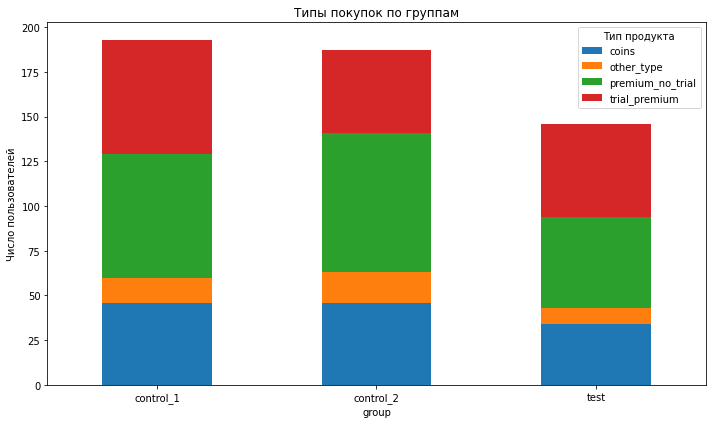

In [26]:
# Строим стопочный график
type_conversion.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Типы покупок по группам")
plt.ylabel("Число пользователей")
plt.xticks(rotation=0)
plt.legend(title="Тип продукта")
plt.tight_layout()
plt.show()

In [30]:
print("\n Сводная информация \n")

for group in ['test', 'control_1', 'control_2']:
    conv = conversion_by_group.loc[group, 'conversion_rate']
    arpu = arpu_by_group[group]
    print(f"Группа: {group} | Конверсия: {conv:.2%} | ARPU: {arpu:.2f}")


 Сводная информация 

Группа: test | Конверсия: 9.47% | ARPU: 544.31
Группа: control_1 | Конверсия: 10.05% | ARPU: 601.91
Группа: control_2 | Конверсия: 9.64% | ARPU: 450.38


In [ ]:
Интерпретация результатов:
1. Конверсия 
    Новый способ оплаты не повлиял на конверсию в премиум-подписку (нет статистически значимых различий).
    Это может означать, что изменение стоимости или способа оплаты не сильно изменило количество пользователей, переходящих на премиум.
2. ARPU
    Новый способ оплаты увеличил среднюю выручку на пользователя (ARPU) по сравнению с контрольной группой 2.
    Однако ARPU ниже, чем в контрольной группе 1. Возможно, это связано с тем, что новая группа содержит меньше пользователей, которые платят через внутреннюю валюту (coins).
3. Типы покупок 
    В тестовой группе наблюдается меньше покупок через внутреннюю валюту (coins) , что может быть связано с изменениями в способе оплаты или цене.
    Покупки премиум-подписки без пробного периода (premium_no_trial) также немного ниже, чем в контрольной группе 2.
Выводы:
    Эксперимент можно считать частично успешным. Хотя конверсия в премиум не изменилась статистически значимо, ARPU в тестовой группе выше, чем в одной из контрольных групп (control_2).
    Это означает, что новые платежные системы могут привести к более высокой выручке на пользователя, даже если общая конверсия остаётся неизменной.
Рекомендации:
    Если цель эксперимента была увеличить ARPU, то новый способ оплаты достиг этой цели.
    Однако, если целью было повысить конверсию, то эксперимент не дал желаемого результата.
    Для дальнейшего улучшения можно провести дополнительные тесты, например:
    Изменить стоимость подписки.
    Оптимизировать процесс оплаты.
    Сегментировать пользователей и проверить, какие группы реагируют лучше на новые платежные системы.